# Cluster sweep analysis

Compares every model trained by the cluster sweep (`cluster/`) across both loss
functions (`cascade`, `abstention`) and all dataset variants (different class
balances + difficulties). Loads the trained checkpoints' metrics and finds the
optimal configurations.

Prereq: run the sweep first (`bash cluster/submit.sh` on SLURM, or
`bash cluster/run_local.sh` locally), then run this notebook from the repo root.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

# find the repo root by walking up until cluster/manifest.json appears
root = Path.cwd()
while not (root / "cluster" / "manifest.json").exists() and root != root.parent:
    root = root.parent
manifest = json.loads((root / "cluster" / "manifest.json").read_text())
print("runs in matrix:", len(manifest["runs"]))


def load_rows():
    """One flat row per run that actually produced a metrics file."""
    rows, missing = [], []
    for r in manifest["runs"]:
        p = root / r["metrics"]
        if not p.exists():
            missing.append(r["run_id"]); continue
        m = json.loads(p.read_text())
        d, mech = m["defect_head"], m["mechanism_accuracy"]
        row = {
            "run_id": r["run_id"], "dataset": r["dataset"], "loss": r["loss"],
            "o": r["o"], "seed": r["seed"],
            "defect_acc": d["accuracy"], "defect_wf1": d["weighted_f1"],
            "defect_macrof1": d["macro_f1"],
            "bayes": m["bayes_optimal_accuracy"],
            "gap_to_bayes": m["bayes_optimal_accuracy"] - d["accuracy"],
            "mech_joint": mech["joint_accuracy"],
            "mech_printing": mech.get("stage_printing"),
            "mech_reflow": mech.get("stage_reflow"),
            "risk_mae": m["risk_mae"],
        }
        ab = m.get("abstention")
        if ab:
            row["mean_abstain"] = ab["mean_abstain_prob"]
            half = ab["by_threshold"].get("0.5", {})
            row["coverage@0.5"] = half.get("coverage")
            row["selective_acc@0.5"] = half.get("selective_accuracy")
        rows.append(row)
    if missing:
        print(f"WARNING: {len(missing)} runs have no metrics yet (still training?):")
        print("  " + ", ".join(missing))
    return pd.DataFrame(rows)


df = load_rows()
print(f"loaded {len(df)} runs")
df.sort_values(["dataset", "loss", "o", "seed"]).reset_index(drop=True)

runs in matrix: 30
loaded 30 runs


,run_id,dataset,loss,o,seed,defect_acc,defect_wf1,defect_macrof1,bayes,gap_to_bayes,mech_joint,mech_printing,mech_reflow,risk_mae,mean_abstain,coverage@0.5,selective_acc@0.5
0,balanced__abstention_o2_s0,balanced,abstention,2.0,0,0.952267,0.952265,0.951248,0.955467,0.003200,0.900500,0.924200,0.931700,0.010752,4.894998e-02,0.962767,0.965066
1,balanced__abstention_o2_s1,balanced,abstention,2.0,1,0.951433,0.951438,0.950773,0.955467,0.004033,0.900333,0.923300,0.932500,0.010872,5.222926e-02,0.963367,0.963288
2,balanced__abstention_o4_s0,balanced,abstention,4.0,0,0.952467,0.952459,0.951381,0.955467,0.003000,0.949500,0.951300,0.958933,0.011743,5.981771e-09,1.000000,0.952467
3,balanced__abstention_o4_s1,balanced,abstention,4.0,1,0.952433,0.952419,0.951396,0.955467,0.003033,0.949167,0.951133,0.959000,0.011655,7.482078e-10,1.000000,0.952433
4,balanced__cascade_s0,balanced,cascade,NaN,0,0.952267,0.952232,0.950988,0.955467,0.003200,0.949467,0.951467,0.957933,0.012221,NaN,NaN,NaN
5,balanced__cascade_s1,balanced,cascade,NaN,1,0.953133,0.953139,0.952113,0.955467,0.002333,0.949067,0.951400,0.958567,0.012233,NaN,NaN,NaN
6,balanced_hard__abstention_o2_s0,balanced_hard,abstention,2.0,0,0.908400,0.908413,0.906453,0.911533,0.003133,0.864333,0.891067,0.891933,0.010802,1.765368e-01,0.840933,0.961788
7,balanced_hard__abstention_o2_s1,balanced_hard,abstention,2.0,1,0.908200,0.908134,0.905612,0.911533,0.003333,0.864367,0.888467,0.895600,0.010248,1.625797e-01,0.863233,0.955053
8,balanced_hard__abstention_o4_s0,balanced_hard,abstention,4.0,0,0.908800,0.908812,0.906880,0.911533,0.002733,0.905367,0.907267,0.921900,0.011377,9.130959e-09,1.000000,0.908800
9,balanced_hard__abstention_o4_s1,balanced_hard,abstention,4.0,1,0.907833,0.907829,0.905717,0.911533,0.003700,0.904500,0.907000,0.921933,0.012337,1.739065e-07,1.000000,0.907833


In [2]:
# Full comparison table, rounded for reading.
cols = ["run_id", "dataset", "loss", "o", "seed", "defect_acc", "defect_macrof1",
        "gap_to_bayes", "mech_joint", "risk_mae", "selective_acc@0.5", "coverage@0.5"]
view = df[[c for c in cols if c in df.columns]].copy()
num = view.select_dtypes("number").columns
view[num] = view[num].round(4)
view.sort_values(["dataset", "loss", "o", "seed"]).reset_index(drop=True)

,run_id,dataset,loss,o,seed,defect_acc,defect_macrof1,gap_to_bayes,mech_joint,risk_mae,selective_acc@0.5,coverage@0.5
0,balanced__abstention_o2_s0,balanced,abstention,2.0,0,0.9523,0.9512,0.0032,0.9005,0.0108,0.9651,0.9628
1,balanced__abstention_o2_s1,balanced,abstention,2.0,1,0.9514,0.9508,0.0040,0.9003,0.0109,0.9633,0.9634
2,balanced__abstention_o4_s0,balanced,abstention,4.0,0,0.9525,0.9514,0.0030,0.9495,0.0117,0.9525,1.0000
3,balanced__abstention_o4_s1,balanced,abstention,4.0,1,0.9524,0.9514,0.0030,0.9492,0.0117,0.9524,1.0000
4,balanced__cascade_s0,balanced,cascade,NaN,0,0.9523,0.9510,0.0032,0.9495,0.0122,NaN,NaN
5,balanced__cascade_s1,balanced,cascade,NaN,1,0.9531,0.9521,0.0023,0.9491,0.0122,NaN,NaN
6,balanced_hard__abstention_o2_s0,balanced_hard,abstention,2.0,0,0.9084,0.9065,0.0031,0.8643,0.0108,0.9618,0.8409
7,balanced_hard__abstention_o2_s1,balanced_hard,abstention,2.0,1,0.9082,0.9056,0.0033,0.8644,0.0102,0.9551,0.8632
8,balanced_hard__abstention_o4_s0,balanced_hard,abstention,4.0,0,0.9088,0.9069,0.0027,0.9054,0.0114,0.9088,1.0000
9,balanced_hard__abstention_o4_s1,balanced_hard,abstention,4.0,1,0.9078,0.9057,0.0037,0.9045,0.0123,0.9078,1.0000


In [3]:
# Average over seeds -> one row per (dataset, loss, o) config.
keys = ["dataset", "loss", "o"]
metrics = ["defect_acc", "defect_macrof1", "gap_to_bayes", "mech_joint",
           "risk_mae"] + [c for c in ("selective_acc@0.5", "coverage@0.5") if c in df.columns]
agg = (df.groupby(keys, dropna=False)[metrics]
         .agg(["mean", "std"]).round(4))
agg

defect_acc         defect_macrof1          \
                                   mean     std           mean     std   
dataset       loss       o                                               
balanced      abstention 2.0     0.9518  0.0006         0.9510  0.0003   
                         4.0     0.9524  0.0000         0.9514  0.0000   
              cascade    NaN     0.9527  0.0006         0.9516  0.0008   
balanced_hard abstention 2.0     0.9083  0.0001         0.9060  0.0006   
                         4.0     0.9083  0.0007         0.9063  0.0008   
              cascade    NaN     0.9085  0.0007         0.9064  0.0011   
baseline      abstention 2.0     0.9085  0.0605         0.5833  0.3875   
                         4.0     0.9514  0.0003         0.8597  0.0017   
              cascade    NaN     0.9512  0.0004         0.8572  0.0006   
hard          abstention 2.0     0.8690  0.0000         0.3100  0.0000   
                         4.0     0.9042  0.0008         0.6571  0.0027   
              cascade    NaN     0.9040  0.0006         0.6546  0.0104   
hard_wide     abstention 2.0     0.8690  0.0000         0.3100  0.0000   
                         4.0     0.9048  0.0005         0.6669  0.0221   
              cascade    NaN     0.9042  0.0009         0.6774  0.0062   

                             gap_to_bayes         mech_joint         risk_mae  \
                                     mean     std       mean     std     mean   
dataset       loss       o                                                      
balanced      abstention 2.0       0.0036  0.0006     0.9004  0.0001   0.0108   
                         4.0       0.0030  0.0000     0.9493  0.0002   0.0117   
              cascade    NaN       0.0028  0.0006     0.9493  0.0003   0.0122   
balanced_hard abstention 2.0       0.0032  0.0001     0.8644  0.0000   0.0105   
                         4.0       0.0032  0.0007     0.9049  0.0006   0.0119   
              cascade    NaN       0.0030  0.0007     0.9053  0.0005   0.0122   
baseline      abstention 2.0       0.0449  0.0605     0.8781  0.0175   0.0096   
                         4.0       0.0021  0.0003     0.9507  0.0004   0.0117   
              cascade    NaN       0.0023  0.0004     0.9501  0.0009   0.0115   
hard          abstention 2.0       0.0373  0.0000     0.8690  0.0000   0.0091   
                         4.0       0.0021  0.0008     0.9042  0.0007   0.0138   
              cascade    NaN       0.0022  0.0006     0.9038  0.0004   0.0122   
hard_wide     abstention 2.0       0.0373  0.0000     0.8690  0.0000   0.0146   
                         4.0       0.0015  0.0005     0.9046  0.0005   0.0162   
              cascade    NaN       0.0021  0.0009     0.9042  0.0008   0.0168   

                                     selective_acc@0.5         coverage@0.5  \
                                 std              mean     std         mean   
dataset       loss       o                                                    
balanced      abstention 2.0  0.0001            0.9642  0.0013       0.9631   
                         4.0  0.0001            0.9524  0.0000       1.0000   
              cascade    NaN  0.0000               NaN     NaN          NaN   
balanced_hard abstention 2.0  0.0004            0.9584  0.0048       0.8521   
                         4.0  0.0007            0.9083  0.0007       1.0000   
              cascade    NaN  0.0005               NaN     NaN          NaN   
baseline      abstention 2.0  0.0002            0.9825  0.0046       0.8709   
                         4.0  0.0008            0.9514  0.0003       1.0000   
              cascade    NaN  0.0018               NaN     NaN          NaN   
hard          abstention 2.0  0.0001            0.9465  0.0031       0.8415   
                         4.0  0.0022            0.9042  0.0008       1.0000   
              cascade    NaN  0.0016               NaN     NaN          NaN   
hard_wide     abstention 2.0  0.0013            0.94

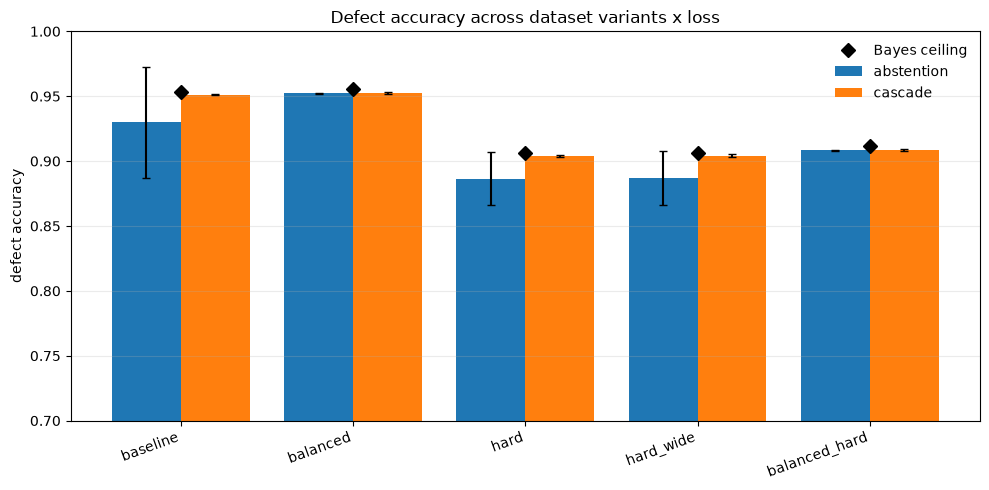

In [4]:
# Defect accuracy by dataset, grouped by loss (mean +/- std over seeds), with the
# Bayes ceiling per dataset for reference.
datasets = list(manifest["datasets"])
losses = sorted(df["loss"].unique())
x = np.arange(len(datasets)); w = 0.8 / max(len(losses), 1)
fig, ax = plt.subplots(figsize=(10, 5))
for i, loss in enumerate(losses):
    means, stds = [], []
    for ds in datasets:
        sub = df[(df.dataset == ds) & (df.loss == loss)]
        means.append(sub["defect_acc"].mean()); stds.append(sub["defect_acc"].std())
    ax.bar(x + i * w, means, w, yerr=stds, capsize=3, label=loss)
# Bayes ceiling (same data regardless of loss) as a marker per dataset
bayes = [df[df.dataset == ds]["bayes"].mean() for ds in datasets]
ax.plot(x + w * (len(losses) - 1) / 2, bayes, "kD", ms=7, label="Bayes ceiling")
ax.set_xticks(x + w * (len(losses) - 1) / 2); ax.set_xticklabels(datasets, rotation=20, ha="right")
ax.set_ylabel("defect accuracy"); ax.set_ylim(0.7, 1.0)
ax.set_title("Defect accuracy across dataset variants x loss")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); plt.show()

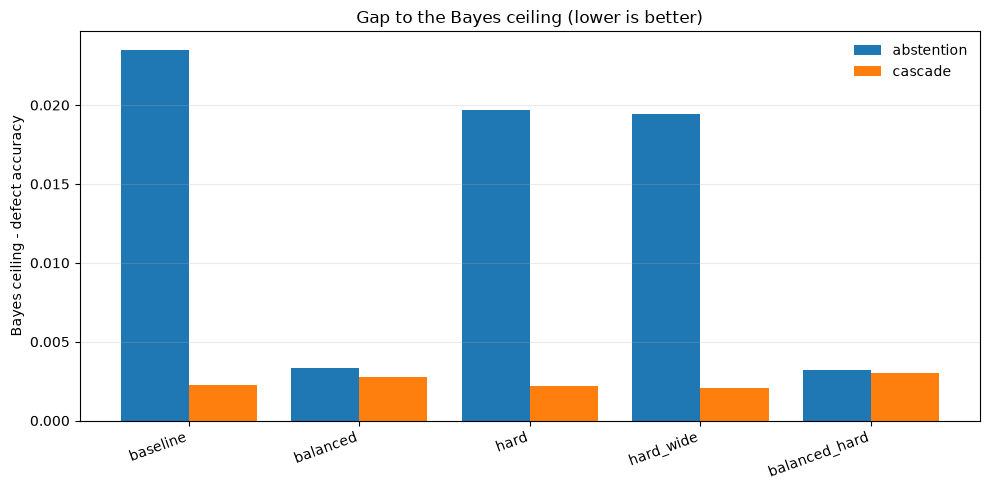

In [5]:
# How far each config sits below its Bayes ceiling (smaller = better).
fig, ax = plt.subplots(figsize=(10, 5))
for i, loss in enumerate(losses):
    means = [df[(df.dataset == ds) & (df.loss == loss)]["gap_to_bayes"].mean()
             for ds in datasets]
    ax.bar(x + i * w, means, w, label=loss)
ax.set_xticks(x + w * (len(losses) - 1) / 2); ax.set_xticklabels(datasets, rotation=20, ha="right")
ax.set_ylabel("Bayes ceiling - defect accuracy"); ax.set_title("Gap to the Bayes ceiling (lower is better)")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
fig.tight_layout(); plt.show()

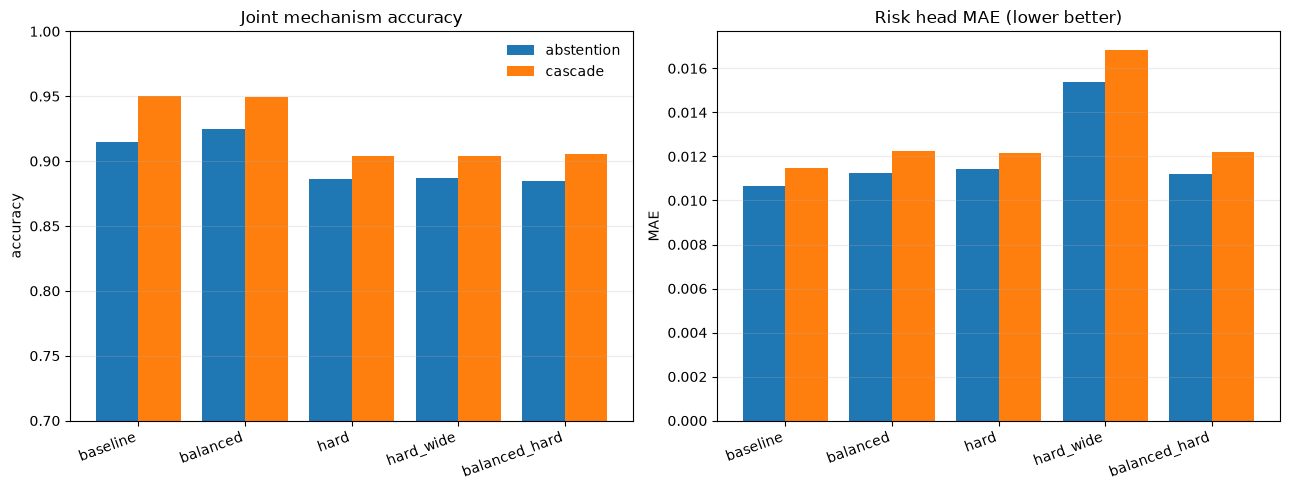

In [6]:
# Mechanism (joint) accuracy and risk MAE side by side, by dataset x loss.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title, lo, hi in [
        (axes[0], "mech_joint", "Joint mechanism accuracy", 0.7, 1.0),
        (axes[1], "risk_mae", "Risk head MAE (lower better)", 0.0, None)]:
    for i, loss in enumerate(losses):
        means = [df[(df.dataset == ds) & (df.loss == loss)][metric].mean() for ds in datasets]
        ax.bar(x + i * w, means, w, label=loss)
    ax.set_xticks(x + w * (len(losses) - 1) / 2); ax.set_xticklabels(datasets, rotation=20, ha="right")
    ax.set_title(title); ax.grid(axis="y", alpha=0.25)
    if lo is not None:
        ax.set_ylim(lo, hi)
axes[0].set_ylabel("accuracy"); axes[1].set_ylabel("MAE"); axes[0].legend(frameon=False)
fig.tight_layout(); plt.show()

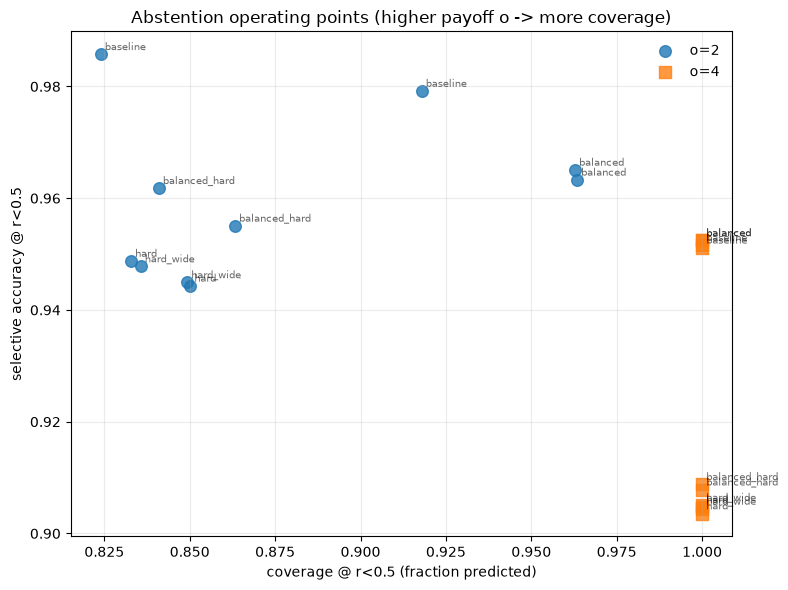

In [7]:
# Abstention only: selective accuracy @0.5 vs coverage @0.5, payoff o encoded by
# marker; one point per (dataset, o, seed). Up-and-right is better.
ab = df[df.loss == "abstention"].dropna(subset=["selective_acc@0.5", "coverage@0.5"])
if len(ab):
    fig, ax = plt.subplots(figsize=(8, 6))
    for o_val, mk in zip(sorted(ab["o"].unique()), ["o", "s", "^", "D"]):
        sub = ab[ab.o == o_val]
        ax.scatter(sub["coverage@0.5"], sub["selective_acc@0.5"], s=70, marker=mk,
                   label=f"o={o_val:g}", alpha=0.8)
        for _, rr in sub.iterrows():
            ax.annotate(rr["dataset"], (rr["coverage@0.5"], rr["selective_acc@0.5"]),
                        fontsize=7, alpha=0.6, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("coverage @ r<0.5 (fraction predicted)")
    ax.set_ylabel("selective accuracy @ r<0.5")
    ax.set_title("Abstention operating points (higher payoff o -> more coverage)")
    ax.legend(frameon=False); ax.grid(alpha=0.25)
    fig.tight_layout(); plt.show()
else:
    print("no abstention runs with metrics yet")

In [8]:
# The optimal configs. "Best" = averaged over seeds so we do not chase noise.
seed_keys = ["dataset", "loss", "o"]
mean_over_seeds = df.groupby(seed_keys, dropna=False).mean(numeric_only=True).reset_index()

def best(metric, maximize=True):
    s = mean_over_seeds.sort_values(metric, ascending=not maximize).iloc[0]
    o = "-" if pd.isna(s["o"]) else f"{s['o']:g}"
    return f"{s['dataset']} / {s['loss']} / o={o}  ->  {metric}={s[metric]:.4f}"

print("=== Most optimal (mean over seeds) ===")
print("highest defect accuracy :", best("defect_acc"))
print("smallest gap to Bayes   :", best("gap_to_bayes", maximize=False))
print("best minority macro-F1  :", best("defect_macrof1"))
print("highest joint mechanism :", best("mech_joint"))
print("lowest risk MAE         :", best("risk_mae", maximize=False))
if "selective_acc@0.5" in mean_over_seeds.columns and mean_over_seeds["selective_acc@0.5"].notna().any():
    ab = mean_over_seeds.dropna(subset=["selective_acc@0.5"])
    s = ab.sort_values("selective_acc@0.5", ascending=False).iloc[0]
    print(f"best selective acc@0.5  : {s['dataset']} / abstention / o={s['o']:g}  ->  "
          f"{s['selective_acc@0.5']:.4f} at coverage {s['coverage@0.5']:.3f}")

print("\n=== Best config per dataset (by gap to Bayes) ===")
for ds in manifest["datasets"]:
    sub = mean_over_seeds[mean_over_seeds.dataset == ds]
    if not len(sub):
        continue
    win = sub.sort_values("gap_to_bayes").iloc[0]
    o = "-" if pd.isna(win["o"]) else f"{win['o']:g}"
    print(f"  {ds:14s} -> {win['loss']:10s} o={o:3s}  "
          f"defect {win['defect_acc']:.4f}  gap {win['gap_to_bayes']:.4f}  "
          f"mech {win['mech_joint']:.4f}  riskMAE {win['risk_mae']:.4f}")

=== Most optimal (mean over seeds) ===
highest defect accuracy : balanced / cascade / o=-  ->  defect_acc=0.9527
smallest gap to Bayes   : hard_wide / abstention / o=4  ->  gap_to_bayes=0.0015
best minority macro-F1  : balanced / cascade / o=-  ->  defect_macrof1=0.9516
highest joint mechanism : baseline / abstention / o=4  ->  mech_joint=0.9507
lowest risk MAE         : hard / abstention / o=2  ->  risk_mae=0.0091
best selective acc@0.5  : baseline / abstention / o=2  ->  0.9825 at coverage 0.871

=== Best config per dataset (by gap to Bayes) ===
  baseline       -> abstention o=4    defect 0.9514  gap 0.0021  mech 0.9507  riskMAE 0.0117
  balanced       -> cascade    o=-    defect 0.9527  gap 0.0028  mech 0.9493  riskMAE 0.0122
  hard           -> abstention o=4    defect 0.9042  gap 0.0021  mech 0.9042  riskMAE 0.0138
  hard_wide      -> abstention o=4    defect 0.9047  gap 0.0015  mech 0.9046  riskMAE 0.0162
  balanced_hard  -> cascade    o=-    defect 0.9085  gap 0.0030  mech 0.90